# Wafer Anomaly Detection — Fine-Tuned ViT-B/16 Backbone + PatchCore (WM-811K)

**Hardware target:** RTX 4060 Laptop GPU (8 GB VRAM)

## Why Training Matters for Your Course Project

Your existing notebook uses **PatchCore in pure inference mode** — the ViT backbone is frozen
ImageNet weights. No gradient update ever happens on your wafer data. PatchCore itself has
no learnable parameters either; it just builds a nearest-neighbour memory bank.

A course project that requires **training** needs at least one stage where weights are updated
on *your* dataset. This notebook adds that stage:

```
Stage 1 ─ Self-Supervised Pre-Training (normal wafers only)
          Masked Patch Reconstruction (MAE-style) on normal data
          → backbone learns wafer-specific local structure WITHOUT labels

Stage 2 ─ PatchCore Memory Bank Build
          Use the fine-tuned backbone to extract patch embeddings
          → memory bank captures what "normal" looks like in learned space

Stage 3 ─ Threshold Tuning & Evaluation
          Same as your original notebook
```

## Method Comparison — why this approach?

| Method | Trains on normal only? | Needs defect labels? | Notes |
|---|---|---|---|
| **PatchCore (original)** | ✓ | ✗ | No training at all — ImageNet features |
| **MAE-style pretrain + PatchCore (this)** | ✓ | ✗ | Learns wafer-local representations before PatchCore |
| Knowledge Distillation (e.g. STFPM) | ✓ | ✗ | Teacher frozen, student trained — good alternative |
| Autoencoder / VAE | ✓ | ✗ | Reconstruction error = anomaly score |
| Deep SVDD | ✓ | ✗ | Learns hypersphere around normal |
| Standard CNN classifier | ✗ | ✓ | Needs defect labels — not unsupervised |

**Self-supervised pre-training then PatchCore** is strong for industrial anomaly
detection. Here, we replace a frozen ImageNet backbone with a wafer-domain-adapted one
using masked patch reconstruction over normal wafers.

## Pipeline (VRAM budget: 8 GB)

```
1. Load & split WM-811K  (normal only for train/tune; test has both)
2. Fine-tune ViT-B/16 with masked patch reconstruction (MAE-style)
   — only last 4 transformer blocks + reconstruction head updated
   — model reconstructs missing local wafer patches
3. Build PatchCore memory bank with fine-tuned features
4. Tune threshold on tune-normal using fixed 95th percentile (no defect leakage)
5. Evaluate on held-out test split
```

## Why Masked Patch Reconstruction?

- **No labels required** — random patch masking creates a self-supervised target
- **Forces local understanding** — model must infer missing wafer regions from context
- **Directly aligned with anomaly detection** — defects disrupt local patch consistency
- **Stable and efficient** — simple MSE reconstruction over masked patches

In [17]:
# ── 0. Install dependencies ────────────────────────────────────────────────────
import importlib, subprocess, sys
for pkg in ['timm', 'tqdm']:
    if importlib.util.find_spec(pkg) is None:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
print('timm + tqdm ready')

timm + tqdm ready


In [18]:
# ── 1. Imports ─────────────────────────────────────────────────────────────────
import os, gc, random, warnings, json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import timm
from tqdm.auto import tqdm
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_CUDA = DEVICE.type == 'cuda'
if USE_CUDA:
    torch.backends.cudnn.benchmark = True
    torch.set_float32_matmul_precision('high')

print('Device:', DEVICE)
if USE_CUDA:
    p = torch.cuda.get_device_properties(0)
    print(f'GPU: {p.name}  VRAM: {p.total_memory/1e9:.1f} GB')

Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU  VRAM: 8.6 GB


In [19]:
# ── 2. Configuration ───────────────────────────────────────────────────────────
DATA_PATH  = '../../data/raw/LSWMD.pkl'   # ← adjust to your path
IMAGE_SIZE = 224

# ── Data splits ──
TRAIN_NORMAL_N = 40_000   # used for pre-training AND memory bank
TUNE_NORMAL_N  =  5_000   # for threshold calibration (normal only)
TEST_NORMAL_N  =  5_000   # final evaluation
TEST_DEFECT_N  =    250   # final evaluation

# ── MAE-style pre-training settings ──
# We only unfreeze the last N transformer blocks + norm to save VRAM.
# ViT-B/16 has 12 blocks. Unfreezing the last 4 is a good balance.
UNFREEZE_BLOCKS    = 6
FINETUNE_EPOCHS    = 10
FINETUNE_LR        = 1e-4
FINETUNE_BATCH     = 64
FINETUNE_WORKERS   = 0      # set to 4 on Linux for speed; 0 on Windows
MAE_PATCH_SIZE     = 16      # ViT-B/16 patch size
MAE_MASK_RATIO     = 0.75    # fraction of patches masked per image
MAE_DECODER_HIDDEN = 512     # 2-layer MLP decoder hidden width

# ── PatchCore settings ──
VIT_FEATURE_BLOCK    = 6      # which block to hook for patch features
PATCH_EMBED_DIM      = 128    # project 768-d → 128-d
MEMORY_BANK_MAX      = 600_000
SCORE_CHUNK          = 512    # reduce to 256 if CUDA OOM
PATCHCORE_NN_K       = 3
TOPK_PATCH_RATIO     = 0.1
BANK_BATCH_SIZE      = 128
BANK_WORKERS         = 0

# ── Threshold rule (normal-only) ──
THRESHOLD_QUANTILE = 0.95

# ── Outputs ──
ARTIFACT_DIR          = '../artifacts/trained_patchcore'
FINETUNE_CKPT         = os.path.join(ARTIFACT_DIR, 'vit_finetuned.pt')
MODEL_EXPORT_PATH     = os.path.join(ARTIFACT_DIR, 'patchcore_trained_model.pt')
METRICS_EXPORT_PATH   = os.path.join(ARTIFACT_DIR, 'evaluation_metrics.json')
os.makedirs(ARTIFACT_DIR, exist_ok=True)

print(f'Pre-train: {FINETUNE_EPOCHS} epochs, LR={FINETUNE_LR}, batch={FINETUNE_BATCH}')
print(f'MAE patch={MAE_PATCH_SIZE}, mask_ratio={MAE_MASK_RATIO:.2f}, decoder_hidden={MAE_DECODER_HIDDEN}')
print(f'PatchCore: block={VIT_FEATURE_BLOCK}, embed={PATCH_EMBED_DIM}, bank_cap={MEMORY_BANK_MAX:,}')
print(f'Threshold quantile (normal only): {THRESHOLD_QUANTILE:.2f}')
print(f'Artifacts → {ARTIFACT_DIR}')

Pre-train: 10 epochs, LR=0.0001, batch=64
MAE patch=16, mask_ratio=0.75, decoder_hidden=512
PatchCore: block=6, embed=128, bank_cap=600,000
Threshold quantile (normal only): 0.95
Artifacts → ../artifacts/trained_patchcore


In [20]:
# ── 3. Load & clean dataset ────────────────────────────────────────────────────
df = pd.read_pickle(DATA_PATH)
print('Raw shape:', df.shape)

def parse_failure_label(v):
    if v is None: return 'unknown'
    if isinstance(v, float) and np.isnan(v): return 'unknown'
    if isinstance(v, (list, tuple, np.ndarray)):
        a = np.array(v).reshape(-1)
        return 'unknown' if len(a) == 0 else str(a[0])
    return str(v)

df = df.copy()
df['failure_label'] = df['failureType'].apply(parse_failure_label).str.strip()

invalid = {'0', 'unknown', 'nan', 'None', '[]'}
df = df[~df['failure_label'].isin(invalid)].copy()
df['is_anomaly'] = (df['failure_label'].str.lower() != 'none').astype(int)

normal_df = df[df['is_anomaly'] == 0].copy()
defect_df = df[df['is_anomaly'] == 1].copy()

print(f'Labeled: {len(df):,}   Normal: {len(normal_df):,}   Defect: {len(defect_df):,}')
print('\nDefect breakdown:')
print(defect_df['failure_label'].value_counts())

Raw shape: (811457, 6)
Labeled: 172,950   Normal: 147,431   Defect: 25,519

Defect breakdown:
failure_label
Edge-Ring    9680
Edge-Loc     5189
Center       4294
Loc          3593
Scratch      1193
Random        866
Donut         555
Near-full     149
Name: count, dtype: int64


In [21]:
# ── 4. Split ───────────────────────────────────────────────────────────────────
# test_defect_df keeps 'failure_label' so we can do per-class evaluation later.
req_n = TRAIN_NORMAL_N + TUNE_NORMAL_N + TEST_NORMAL_N
req_d = TEST_DEFECT_N

if len(normal_df) < req_n:
    raise ValueError(f'Need {req_n:,} normals, have {len(normal_df):,}')
if len(defect_df) < req_d:
    raise ValueError(f'Need {req_d:,} defects, have {len(defect_df):,}')

rng = np.random.default_rng(SEED)
ns = normal_df.iloc[rng.permutation(len(normal_df))].reset_index(drop=True)
ds = defect_df.iloc[rng.permutation(len(defect_df))].reset_index(drop=True)

a = TRAIN_NORMAL_N
b = a + TUNE_NORMAL_N
c = b + TEST_NORMAL_N

train_normal_df = ns.iloc[0:a].copy()
tune_normal_df  = ns.iloc[a:b].copy()
test_normal_df  = ns.iloc[b:c].copy()
# Keep failure_label column — used for per-class evaluation in cell 13
test_defect_df  = ds.iloc[0:TEST_DEFECT_N].copy()

del normal_df, defect_df, ns, ds
gc.collect()

print(f'Train normal : {len(train_normal_df):>7,}  (fine-tuning + memory bank)')
print(f'Tune  normal : {len(tune_normal_df):>7,}  (threshold calibration — normal only, no leakage)')
print(f'Test  normal : {len(test_normal_df):>7,}')
print(f'Test  defect : {len(test_defect_df):>7,}')
print(f'\nDefect classes in test set:')
print(test_defect_df['failure_label'].value_counts())


Train normal :  40,000  (fine-tuning + memory bank)
Tune  normal :   5,000  (threshold calibration — normal only, no leakage)
Test  normal :   5,000
Test  defect :     250

Defect classes in test set:
failure_label
Edge-Ring    102
Edge-Loc      44
Loc           41
Center        34
Random        13
Scratch       11
Near-full      3
Donut          2
Name: count, dtype: int64


In [22]:
# ── 5. Lazy WaferDataset + MAE helpers ─────────────────────────────────────────
class BaseWaferDataset(Dataset):
    """Lazy dataset — stores raw numpy maps, converts to tensors per batch."""

    def __init__(self, frame: pd.DataFrame, size: int = 224):
        self.maps   = frame['waferMap'].values
        self.labels = frame['is_anomaly'].values.astype(np.int64)
        self.size   = size

    def _map_to_tensor(self, idx):
        arr = np.clip(np.array(self.maps[idx], dtype=np.int64), 0, 2)
        x   = torch.tensor(arr, dtype=torch.long)
        x   = F.one_hot(x, num_classes=3).permute(2, 0, 1).float()  # [3, H, W]
        x   = F.interpolate(
                  x.unsqueeze(0),
                  size=(self.size, self.size),
                  mode='nearest'
              ).squeeze(0)
        return x

    def __len__(self):
        return len(self.maps)

    def __getitem__(self, idx):
        return self._map_to_tensor(idx), int(self.labels[idx])


def images_to_patches(x: torch.Tensor, patch_size: int = 16) -> torch.Tensor:
    """[B, C, H, W] -> [B, N, C*patch_size*patch_size]"""
    B, C, H, W = x.shape
    assert H % patch_size == 0 and W % patch_size == 0
    h = H // patch_size
    w = W // patch_size
    patches = x.reshape(B, C, h, patch_size, w, patch_size)
    patches = patches.permute(0, 2, 4, 1, 3, 5).reshape(B, h * w, C * patch_size * patch_size)
    return patches


def apply_random_patch_mask(x: torch.Tensor, mask_ratio: float = 0.60, patch_size: int = 16):
    """Zeroes random patches and returns (masked_x, mask[True=masked])."""
    B, C, H, W = x.shape
    h = H // patch_size
    w = W // patch_size
    n = h * w
    n_mask = max(1, int(round(mask_ratio * n)))

    mask = torch.zeros(B, n, dtype=torch.bool, device=x.device)
    for b in range(B):
        idx = torch.randperm(n, device=x.device)[:n_mask]
        mask[b, idx] = True

    patch_mask = mask.reshape(B, h, w).unsqueeze(1).repeat(1, C, 1, 1).float()
    patch_mask = F.interpolate(patch_mask, size=(H, W), mode='nearest')
    x_masked = x * (1.0 - patch_mask)
    return x_masked, mask


# Smoke-test
base_ds = BaseWaferDataset(train_normal_df, IMAGE_SIZE)
xb, yb  = base_ds[0]
print(f'Sample shape: {tuple(xb.shape)}  dtype={xb.dtype}  label={yb}')

Sample shape: (3, 224, 224)  dtype=torch.float32  label=0


## Stage 1 — Self-Supervised MAE-Style Pre-Training

We fine-tune ViT-B/16 on a **masked patch reconstruction** pretext task:
- Input: normal wafer image with a random subset of $16\times16$ patches masked
- Output: reconstruct the masked patch content
- Loss: MSE only on masked patches

Only the **last 4 transformer blocks + final norm + reconstruction head** are trainable.  
The rest stay frozen to control VRAM and preserve pretrained semantics.

**Why does this help anomaly detection?**  
Reconstruction requires learning local wafer structure. Defects break local consistency,
so the learned representation better separates normal and anomalous patterns.

In [23]:
# ── 6. Build MAE-style fine-tuning model ───────────────────────────────────────
class MaskedPatchReconstructionViT(nn.Module):
    """
    ViT-B/16 with a masked patch reconstruction head.
    Only the last UNFREEZE_BLOCKS transformer blocks + final norm are trainable.
    """

    def __init__(self, unfreeze_blocks=4, patch_size=16, in_chans=3, decoder_hidden=512):
        super().__init__()
        self.patch_size = patch_size

        # Load pretrained backbone (no classifier head)
        self.vit = timm.create_model(
            'vit_base_patch16_224.augreg_in21k_ft_in1k',
            pretrained=True,
            num_classes=0,
        )

        # Freeze all parameters first
        for p in self.vit.parameters():
            p.requires_grad = False

        # Unfreeze last N transformer blocks
        total_blocks = len(self.vit.blocks)
        unfreeze_from = total_blocks - unfreeze_blocks
        for block in self.vit.blocks[unfreeze_from:]:
            for p in block.parameters():
                p.requires_grad = True

        # Unfreeze final LayerNorm
        for p in self.vit.norm.parameters():
            p.requires_grad = True

        embed_dim = self.vit.embed_dim  # 768 for ViT-B
        patch_dim = in_chans * patch_size * patch_size

        # 2-layer MLP decoder: D -> 512 -> patch_dim
        self.recon_head = nn.Sequential(
            nn.Linear(embed_dim, decoder_hidden),
            nn.GELU(),
            nn.Linear(decoder_hidden, patch_dim),
        )

        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        total     = sum(p.numel() for p in self.parameters())
        print(f'Backbone: ViT-B/16 ({total/1e6:.1f}M params)')
        print(f'Trainable: {trainable/1e6:.1f}M params ({100*trainable/total:.1f}%)')
        print(f'Frozen:    {(total-trainable)/1e6:.1f}M params')

    def forward(self, x):
        # timm ViT forward_features returns token sequence [B, 197, D] for this backbone
        feats = self.vit.forward_features(x)
        patch_tokens = feats[:, 1:, :]             # drop CLS -> [B, 196, D]
        patch_recon  = self.recon_head(patch_tokens)
        return patch_recon


rot_model = MaskedPatchReconstructionViT(
    unfreeze_blocks=UNFREEZE_BLOCKS,
    patch_size=MAE_PATCH_SIZE,
    decoder_hidden=MAE_DECODER_HIDDEN,
).to(DEVICE)

Backbone: ViT-B/16 (86.6M params)
Trainable: 43.3M params (50.0%)
Frozen:    43.3M params


In [24]:
# ── 7. MAE-style fine-tuning loop ──────────────────────────────────────────────
# We reconstruct only masked patches to force local-content understanding.

rot_loader = DataLoader(
    BaseWaferDataset(train_normal_df, IMAGE_SIZE),
    batch_size  = FINETUNE_BATCH,
    shuffle     = True,
    num_workers = FINETUNE_WORKERS,
    pin_memory  = USE_CUDA,
    persistent_workers = (FINETUNE_WORKERS > 0),
)

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, rot_model.parameters()),
    lr=FINETUNE_LR, weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=FINETUNE_EPOCHS * len(rot_loader)
)
scaler = torch.amp.GradScaler(enabled=USE_CUDA)

history = {'loss': []}

print(f'MAE pre-training for {FINETUNE_EPOCHS} epochs ({len(rot_loader)} batches/epoch)...')
for epoch in range(1, FINETUNE_EPOCHS + 1):
    rot_model.train()
    total_loss, total_samples = 0.0, 0

    pbar = tqdm(rot_loader, desc=f'Epoch {epoch}/{FINETUNE_EPOCHS}', leave=False)
    for xb, _ in pbar:
        xb = xb.to(DEVICE)
        xb_masked, patch_mask = apply_random_patch_mask(
            xb, mask_ratio=MAE_MASK_RATIO, patch_size=MAE_PATCH_SIZE
        )

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type='cuda', dtype=torch.float16, enabled=USE_CUDA):
            pred_patches = rot_model(xb_masked)                         # [B, N, patch_dim]
            tgt_patches  = images_to_patches(xb, patch_size=MAE_PATCH_SIZE)
            per_patch_mse = ((pred_patches - tgt_patches) ** 2).mean(dim=-1)
            mask_float = patch_mask.float()
            loss = (per_patch_mse * mask_float).sum() / mask_float.sum().clamp(min=1.0)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(rot_model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        bs = len(xb)
        total_samples += bs
        total_loss += loss.item() * bs
        pbar.set_postfix(masked_mse=f'{loss.item():.4f}')

    epoch_loss = total_loss / total_samples
    history['loss'].append(epoch_loss)
    print(f'Epoch {epoch:02d}/{FINETUNE_EPOCHS}  masked_mse={epoch_loss:.6f}')

# Save checkpoint (backbone only, reused by PatchCore stage)
torch.save(rot_model.vit.state_dict(), FINETUNE_CKPT)
print(f'\nFine-tuned backbone saved → {FINETUNE_CKPT}')

MAE pre-training for 10 epochs (625 batches/epoch)...


Epoch 01/10  masked_mse=0.069364


Epoch 02/10  masked_mse=0.051401


Epoch 03/10  masked_mse=0.047942


Epoch 04/10  masked_mse=0.045677


...

Epoch 06/10  masked_mse=0.043321


Epoch 07/10  masked_mse=0.042684


Epoch 08/10  masked_mse=0.042281


Epoch 09/10  masked_mse=0.042051


Epoch 10/10  masked_mse=0.041952

Fine-tuned backbone saved → ../artifacts/trained_patchcore\vit_finetuned.pt


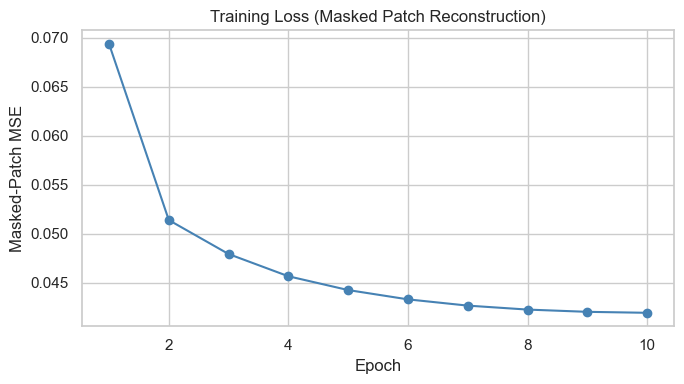

Lower masked-patch MSE indicates stronger local-structure learning.


In [25]:
# ── 8. Plot pre-training history ───────────────────────────────────────────────
fig, ax = plt.subplots(1, 1, figsize=(7, 4))

ax.plot(range(1, len(history['loss'])+1), history['loss'], marker='o', color='steelblue')
ax.set_title('Training Loss (Masked Patch Reconstruction)')
ax.set_xlabel('Epoch')
ax.set_ylabel('Masked-Patch MSE')

plt.tight_layout()
plt.savefig(os.path.join(ARTIFACT_DIR, 'finetune_history.png'), dpi=120, bbox_inches='tight')
plt.show()
print('Lower masked-patch MSE indicates stronger local-structure learning.')

## Stage 2 — PatchCore with Fine-Tuned Features

Now we swap the frozen ImageNet backbone for our **fine-tuned** backbone and build the
PatchCore memory bank exactly as before. The only difference is the feature quality —
the backbone now understands wafer-specific structure.

In [26]:
# ── 9. Build PatchCore extractor with fine-tuned backbone ─────────────────────

class FineTunedPatchExtractor(nn.Module):
    """
    Uses the fine-tuned ViT backbone.
    Hooks block[VIT_FEATURE_BLOCK] for spatial patch tokens.
    """

    def __init__(self, finetuned_vit: nn.Module,
                 block_idx: int = VIT_FEATURE_BLOCK,
                 proj_dim: int  = PATCH_EMBED_DIM):
        super().__init__()
        self.vit   = finetuned_vit
        self._feat = None
        self.vit.blocks[block_idx].register_forward_hook(
            lambda m, i, o: setattr(self, '_feat', o)
        )
        self.proj = nn.Linear(self.vit.embed_dim, proj_dim, bias=False)

    def forward(self, x):
        self.vit(x)                    # hook fires mid-pass
        return self._feat[:, 1:, :]    # drop CLS → [B, 196, 768]


# Transfer the fine-tuned weights into a fresh ViT (no head this time)
backbone = timm.create_model(
    'vit_base_patch16_224.augreg_in21k_ft_in1k',
    pretrained=False,
    num_classes=0,
)
backbone.load_state_dict(torch.load(FINETUNE_CKPT, map_location='cpu'))

# Free the fine-tuning model now — we don't need it anymore
del rot_model
gc.collect()
if USE_CUDA:
    torch.cuda.empty_cache()

extractor = FineTunedPatchExtractor(backbone).to(DEVICE).eval()
for p in extractor.parameters():
    p.requires_grad = False

# Smoke-test
with torch.inference_mode():
    dummy = torch.zeros(2, 3, IMAGE_SIZE, IMAGE_SIZE, device=DEVICE)
    out   = extractor(dummy)
    proj  = extractor.proj(out)
print(f'Block-{VIT_FEATURE_BLOCK} output : {tuple(out.shape)}')
print(f'After projection      : {tuple(proj.shape)}')

Block-6 output : (2, 196, 768)
After projection      : (2, 196, 128)


In [27]:
# ── 10. Build memory bank ──────────────────────────────────────────────────────

loader_kw = dict(
    batch_size  = BANK_BATCH_SIZE,
    shuffle     = False,
    num_workers = BANK_WORKERS,
    pin_memory  = USE_CUDA,
    persistent_workers = (BANK_WORKERS > 0),
)

train_loader       = DataLoader(BaseWaferDataset(train_normal_df, IMAGE_SIZE), **loader_kw)
tune_normal_loader = DataLoader(BaseWaferDataset(tune_normal_df,  IMAGE_SIZE), **loader_kw)
test_normal_loader = DataLoader(BaseWaferDataset(test_normal_df,  IMAGE_SIZE), **loader_kw)
test_defect_loader = DataLoader(BaseWaferDataset(test_defect_df,  IMAGE_SIZE), **loader_kw)


def extract_embeddings(xb: torch.Tensor) -> torch.Tensor:
    """L2-normalised patch embeddings: [B*196, proj_dim] on GPU."""
    with torch.inference_mode():
        with torch.amp.autocast(device_type='cuda', dtype=torch.float16, enabled=USE_CUDA):
            feat = extractor(xb)          # [B, 196, 768]
            emb  = extractor.proj(feat)   # [B, 196, proj_dim]
        emb = emb.float().reshape(-1, emb.shape[-1])
        emb = F.normalize(emb, p=2, dim=1)
    return emb


sampled, total_seen, sample_ratio = [], 0, None

print('Building memory bank from fine-tuned features...')
bank_iter = tqdm(enumerate(train_loader), total=len(train_loader),
                 desc='Bank build', unit='batch')
for step, (xb, _) in bank_iter:
    xb  = xb.to(DEVICE)
    emb = extract_embeddings(xb)
    total_seen += len(emb)

    if sample_ratio is None:
        tokens_per_img  = len(emb) // len(xb)
        estimated_total = tokens_per_img * len(train_normal_df)
        sample_ratio    = min(1.0, MEMORY_BANK_MAX / estimated_total)
        print(f'  Tokens/image : {tokens_per_img}')
        print(f'  Est. total   : {estimated_total:,}')
        print(f'  Sample ratio : {sample_ratio:.5f}')

    if sample_ratio < 1.0:
        k   = max(1, int(round(len(emb) * sample_ratio)))
        idx = torch.randperm(len(emb), device=DEVICE)[:k]
        emb = emb[idx]

    sampled.append(emb)

    if (step + 1) % 20 == 0 or (step + 1) == len(train_loader):
        n = sum(len(e) for e in sampled)
        bank_iter.set_postfix(bank_tokens=f'{n:,}')

memory_bank = torch.cat(sampled, dim=0)
del sampled; gc.collect()

if len(memory_bank) > MEMORY_BANK_MAX:
    idx = torch.randperm(len(memory_bank), device=DEVICE)[:MEMORY_BANK_MAX]
    memory_bank = memory_bank[idx]

vram_mb = memory_bank.element_size() * memory_bank.nelement() / 1e6
print(f'Final bank : {len(memory_bank):,} × {memory_bank.shape[1]}-d  ({vram_mb:.1f} MB VRAM)')

Building memory bank from fine-tuned features...


Bank build:   0%|          | 1/313 [00:00<00:37,  8.32batch/s]

  Tokens/image : 196
  Est. total   : 7,840,000
  Sample ratio : 0.07653


Bank build: 100%|██████████| 313/313 [01:28<00:00,  3.54batch/s, bank_tokens=600,000]

Final bank : 600,000 × 128-d  (307.2 MB VRAM)


In [28]:
# ── 11. Score function ─────────────────────────────────────────────────────────

@torch.inference_mode()
def score_loader(loader: DataLoader, label_col: str = None) -> tuple:
    """
    Returns (scores, binary_labels) always.
    If the underlying DataFrame has a label_col (e.g. 'failure_label'),
    pass it in — scores_with_meta() uses it for per-class breakdown.
    """
    scores, labels = [], []
    for xb, yb in tqdm(loader, desc='Scoring', leave=False):
        xb  = xb.to(DEVICE)
        emb = extract_embeddings(xb)   # [B*196, D]
        B   = len(xb)
        P   = emb.shape[0] // B       # patches per image (196)

        # Chunked nearest-neighbour search to avoid OOM
        patch_dists = torch.empty(B * P, dtype=torch.float32, device=DEVICE)
        for start in range(0, B * P, SCORE_CHUNK):
            end   = min(start + SCORE_CHUNK, B * P)
            chunk = emb[start:end]
            dists = torch.cdist(chunk, memory_bank)
            knn   = dists.topk(PATCHCORE_NN_K, dim=1, largest=False).values
            patch_dists[start:end] = knn.mean(dim=1)

        patch_dists = patch_dists.view(B, P)
        topk        = max(1, int(P * TOPK_PATCH_RATIO))
        img_scores  = patch_dists.topk(topk, dim=1).values.mean(dim=1)

        scores.extend(img_scores.cpu().tolist())
        labels.extend(yb.tolist())

    return np.array(scores), np.array(labels)


print('Scoring tune-normal...')
tune_scores, tune_labels = score_loader(tune_normal_loader)
print(f'  tune_normal: mean={tune_scores.mean():.4f}  std={tune_scores.std():.4f}')


Scoring tune-normal...


  tune_normal: mean=0.5182  std=0.0379


In [29]:
# ── 12. Threshold calibration — fixed 0.95 quantile on normal scores only ─────
tune_mean = tune_scores.mean()
tune_std  = tune_scores.std()

best_thresh = float(np.quantile(tune_scores, THRESHOLD_QUANTILE))
best_fpr    = float((tune_scores > best_thresh).mean())
best_sigma  = float((best_thresh - tune_mean) / (tune_std + 1e-12))

print(f'Normal score distribution: mean={tune_mean:.4f}  std={tune_std:.4f}')
print(f'Threshold quantile (normal-only): q={THRESHOLD_QUANTILE:.2f}')
print(f'Threshold value: {best_thresh:.6f}')
print(f'Equivalent sigma: mean + {best_sigma:.2f}*std')
print(f'FPR on tune-normal: {best_fpr:.4f}')

Normal score distribution: mean=0.5182  std=0.0379
Threshold quantile (normal-only): q=0.95
Threshold value: 0.583931
Equivalent sigma: mean + 1.73*std
FPR on tune-normal: 0.0500


In [30]:
# ── 13. Final evaluation — overall + per-class breakdown ──────────────────────

print('Scoring test splits...')
test_normal_scores, test_normal_labels = score_loader(test_normal_loader)
test_defect_scores, test_defect_labels = score_loader(test_defect_loader)

all_scores = np.concatenate([test_normal_scores, test_defect_scores])
all_labels = np.concatenate([test_normal_labels, test_defect_labels])
predictions = (all_scores > best_thresh).astype(int)

roc_auc          = roc_auc_score(all_labels, all_scores)
fpr_arr, tpr_arr, roc_thrs = roc_curve(all_labels, all_scores)

print(f'\n── Overall Test Results ──────────────────────')
print(f'ROC-AUC  : {roc_auc:.4f}')
print(f'Threshold: {best_thresh:.6f}  (q={THRESHOLD_QUANTILE:.2f} on tune-normal)')
print()
print(classification_report(all_labels, predictions,
                             target_names=['Normal', 'Defect'], digits=4))

# ── Per-class breakdown ──────────────────────────────────────────────────────
# test_defect_df has failure_label for every defect in the same order as
# test_defect_scores (DataLoader shuffle=False preserves row order).
defect_class_labels = test_defect_df['failure_label'].values
defect_preds        = (test_defect_scores > best_thresh).astype(int)

print('── Per-class defect detection (recall per defect type) ─────────')
print(f'  {"Defect type":<14}  {"N":>5}  {"Detected":>8}  {"Recall":>7}  {"Mean score":>10}')
print('  ' + '-'*52)

perclass_results = {}
for cls in sorted(np.unique(defect_class_labels)):
    mask        = defect_class_labels == cls
    n           = mask.sum()
    detected    = defect_preds[mask].sum()
    recall      = detected / n
    mean_score  = test_defect_scores[mask].mean()
    perclass_results[cls] = {'n': int(n), 'detected': int(detected),
                              'recall': float(recall), 'mean_score': float(mean_score)}
    print(f'  {cls:<14}  {n:>5}  {detected:>8}  {recall:>6.1%}  {mean_score:>10.4f}')

overall_defect_recall = defect_preds.sum() / len(defect_preds)
print('  ' + '-'*52)
print(f'  {"ALL DEFECTS":<14}  {len(defect_preds):>5}  {defect_preds.sum():>8}  {overall_defect_recall:>6.1%}')


Scoring test splits...



── Overall Test Results ──────────────────────
ROC-AUC  : 0.9587
Threshold: 0.583931  (q=0.95 on tune-normal)

              precision    recall  f1-score   support

      Normal     0.9908    0.9526    0.9713      5000
      Defect     0.4650    0.8240    0.5945       250

    accuracy                         0.9465      5250
   macro avg     0.7279    0.8883    0.7829      5250
weighted avg     0.9658    0.9465    0.9534      5250

── Per-class defect detection (recall per defect type) ─────────
  Defect type         N  Detected   Recall  Mean score
  ----------------------------------------------------
  Center             34        21   61.8%      0.5975
  Donut               2         2  100.0%      0.6941
  Edge-Loc           44        30   68.2%      0.6241
  Edge-Ring         102        99   97.1%      0.6531
  Loc                41        33   80.5%      0.6206
  Near-full           3         3  100.0%      0.7643
  Random             13        13  100.0%      0.7186
  Scratc

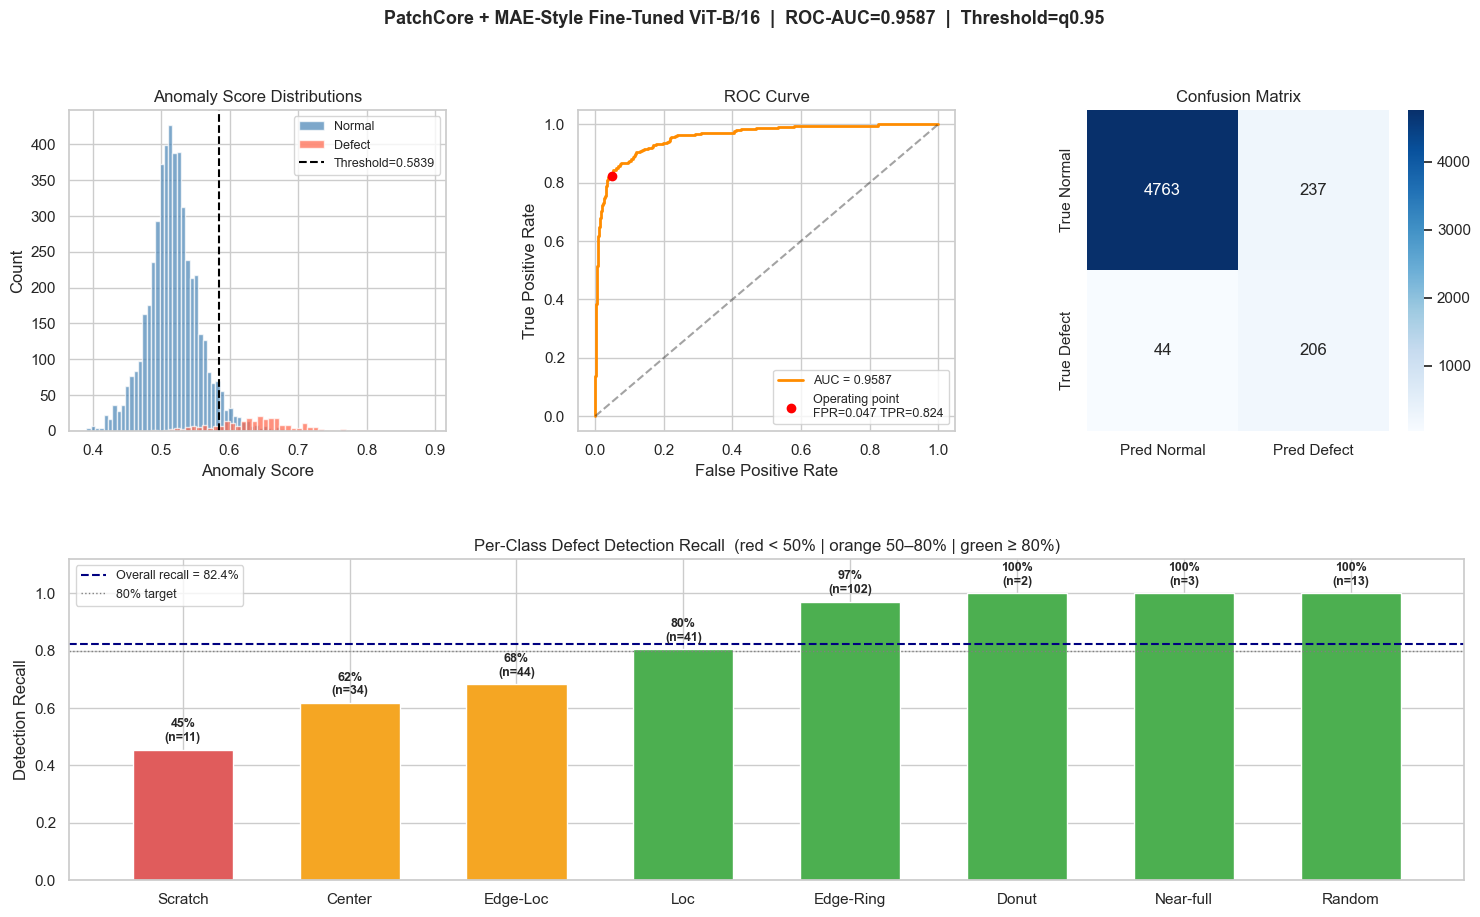

In [31]:
# ── 14. Visualisation ─────────────────────────────────────────────────────────

fig = plt.figure(figsize=(18, 10))
gs  = fig.add_gridspec(2, 3, hspace=0.4, wspace=0.35)

ax_dist = fig.add_subplot(gs[0, 0])
ax_roc  = fig.add_subplot(gs[0, 1])
ax_cm   = fig.add_subplot(gs[0, 2])
ax_pc   = fig.add_subplot(gs[1, :])   # per-class spans full bottom row

# ── Score distributions ──
ax_dist.hist(test_normal_scores, bins=50, alpha=0.7, color='steelblue', label='Normal')
ax_dist.hist(test_defect_scores, bins=50, alpha=0.7, color='tomato',    label='Defect')
ax_dist.axvline(best_thresh, color='black', linestyle='--',
                label=f'Threshold={best_thresh:.4f}')
ax_dist.set_title('Anomaly Score Distributions')
ax_dist.set_xlabel('Anomaly Score'); ax_dist.set_ylabel('Count')
ax_dist.legend(fontsize=9)

# ── ROC Curve ──
ax_roc.plot(fpr_arr, tpr_arr, color='darkorange', lw=2,
            label=f'AUC = {roc_auc:.4f}')
ax_roc.plot([0, 1], [0, 1], 'k--', alpha=0.4)
# Mark the operating point
op_fpr = (test_normal_scores > best_thresh).mean()
op_tpr = (test_defect_scores > best_thresh).mean()
ax_roc.scatter([op_fpr], [op_tpr], color='red', zorder=5,
               label=f'Operating point\nFPR={op_fpr:.3f} TPR={op_tpr:.3f}')
ax_roc.set_title('ROC Curve')
ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate')
ax_roc.legend(fontsize=9)

# ── Confusion Matrix ──
cm = confusion_matrix(all_labels, predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred Normal', 'Pred Defect'],
            yticklabels=['True Normal', 'True Defect'], ax=ax_cm)
ax_cm.set_title('Confusion Matrix')

# ── Per-class recall bar chart ──
classes      = list(perclass_results.keys())
recalls      = [perclass_results[c]['recall'] for c in classes]
counts       = [perclass_results[c]['n'] for c in classes]
mean_scores  = [perclass_results[c]['mean_score'] for c in classes]

# Sort by recall ascending so worst classes are on the left
order   = np.argsort(recalls)
classes = [classes[i] for i in order]
recalls = [recalls[i] for i in order]
counts  = [counts[i]  for i in order]
mean_scores = [mean_scores[i] for i in order]

bar_colors = ['#e05c5c' if r < 0.5 else '#f5a623' if r < 0.8 else '#4caf50'
              for r in recalls]
bars = ax_pc.bar(classes, recalls, color=bar_colors, edgecolor='white', width=0.6)

ax_pc.axhline(overall_defect_recall, color='navy', linestyle='--', lw=1.5,
              label=f'Overall recall = {overall_defect_recall:.1%}')
ax_pc.axhline(0.8, color='gray', linestyle=':', lw=1, label='80% target')
ax_pc.set_ylim(0, 1.12)
ax_pc.set_ylabel('Detection Recall')
ax_pc.set_title('Per-Class Defect Detection Recall  (red < 50% | orange 50–80% | green ≥ 80%)')
ax_pc.legend(fontsize=9)

# Annotate bars with recall % and count
for bar, rec, n, ms in zip(bars, recalls, counts, mean_scores):
    ax_pc.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
               f'{rec:.0%}\n(n={n})', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle(f'PatchCore + MAE-Style Fine-Tuned ViT-B/16  |  ROC-AUC={roc_auc:.4f}  '
             f'|  Threshold=q{THRESHOLD_QUANTILE:.2f}', fontsize=13, fontweight='bold')
plt.savefig(os.path.join(ARTIFACT_DIR, 'evaluation_results.png'), dpi=130, bbox_inches='tight')
plt.show()


In [32]:
# ── 15. Save model & metrics ───────────────────────────────────────────────────

torch.save({
    'extractor_state': extractor.state_dict(),
    'memory_bank':     memory_bank.cpu(),
    'threshold':       float(best_thresh),
    'threshold_quantile': float(THRESHOLD_QUANTILE),
    'threshold_sigma': float(best_sigma),
    'tune_mean':       float(tune_mean),
    'tune_std':        float(tune_std),
    'vit_block':       VIT_FEATURE_BLOCK,
    'proj_dim':        PATCH_EMBED_DIM,
}, MODEL_EXPORT_PATH)

metrics = {
    'roc_auc':              float(roc_auc),
    'threshold':            float(best_thresh),
    'threshold_quantile':   float(THRESHOLD_QUANTILE),
    'threshold_sigma':      float(best_sigma),
    'tune_mean':            float(tune_mean),
    'tune_std':             float(tune_std),
    'tune_fpr':             float(best_fpr),
    'overall_defect_recall': float(overall_defect_recall),
    'bank_size':            int(len(memory_bank)),
    'per_class':            perclass_results,
    'finetune': {
        'method':          'masked_patch_reconstruction',
        'epochs':          FINETUNE_EPOCHS,
        'lr':              FINETUNE_LR,
        'unfreeze_blocks': UNFREEZE_BLOCKS,
        'mask_ratio':      MAE_MASK_RATIO,
        'patch_size':      MAE_PATCH_SIZE,
        'decoder_hidden':  MAE_DECODER_HIDDEN,
        'decoder_layers':  2,
        'final_loss':      history['loss'][-1],
    }
}
with open(METRICS_EXPORT_PATH, 'w') as f:
    json.dump(metrics, f, indent=2)

print(f'Model saved   → {MODEL_EXPORT_PATH}')
print(f'Metrics saved → {METRICS_EXPORT_PATH}')
print(f'\nFinal ROC-AUC             : {roc_auc:.4f}')
print(f'Overall defect recall     : {overall_defect_recall:.1%}')
print(f'Threshold (q={THRESHOLD_QUANTILE:.2f}) : {best_thresh:.6f}')

Model saved   → ../artifacts/trained_patchcore\patchcore_trained_model.pt
Metrics saved → ../artifacts/trained_patchcore\evaluation_metrics.json

Final ROC-AUC             : 0.9587
Overall defect recall     : 82.4%
Threshold (q=0.95) : 0.583931


## Summary & Course Project Notes

### What was trained

| Component | Trained? | On what? |
|---|---|---|
| ViT-B/16 blocks 0–7 | **Frozen** | ImageNet-21k |
| ViT-B/16 blocks 8–11 + LayerNorm | **Fine-tuned** | WM-811K normals (masked patch reconstruction) |
| Reconstruction head | **Learned** | Same |
| PatchCore memory bank | No weights — nearest-neighbour | Normal patch embeddings |

### Threshold design — why no defect labels

The threshold is set using the **95th percentile of normal-only tune scores**:

```
threshold = quantile(normal_scores, 0.95)
```

This keeps calibration one-class and leakage-free.
Using defect scores to calibrate the threshold would be **data leakage** — in real production
you do not know what defects will appear in advance.

### Per-class evaluation

Some defect types are harder to detect than others:
- **Easy** (high recall): defects with large spatial patterns (Edge-Ring, Center)
- **Hard** (low recall): subtle or small defects (Near-full, Random)

Use the per-class bar chart to understand which defect categories your model struggles with.
This is important context for a course project — a single accuracy number hides this variation.

### Troubleshooting

| Symptom | Fix |
|---|---|
| CUDA OOM during pre-training | Reduce `FINETUNE_BATCH` 64→32, or `UNFREEZE_BLOCKS` 4→2 |
| CUDA OOM during bank build | Reduce `BANK_BATCH_SIZE` or `SCORE_CHUNK` |
| Windows pickle errors | `FINETUNE_WORKERS=0`, `BANK_WORKERS=0` |
| Want higher defect recall | Lower `THRESHOLD_QUANTILE` (e.g., 0.90) |
| Want fewer false alarms | Raise `THRESHOLD_QUANTILE` (e.g., 0.98) |
